## Reinforcement Learning

    -> MDPs (mathematical model)
        (S, A, P, R, γ)

    → Bellman equations
        → Expectation Bellman equation (EB)
        → Optimality Bellman equation (OP)

    → Model-Based (Planning/DP -> when model is known)(solves Bellman exactly)
        → Dynamic Programming
            → Value Iteration (OP)
            → Policy Iteration (EB)
                → Policy Evaluation (EB)
                → Policy Improvement (Greedy)

    → Model-Free (Learning -> when model is unknown)(approximates Bellman from samples)
        → Monte Carlo
        → Temporal Difference (TD)
            → SARSA (on-policy)
            → Q-learning (off-policy)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

In [2]:
class gridworld:
    def __init__(self, size=4):
        self.size = size
        self.walls = {(2, 2)}
        self.terminal_rewards = {(3, 0): 100, 
                                 (1, 3): -100} # Terminal states with rewards

    def is_terminal(self, state):
        return state in self.terminal_rewards

    def transition(self, state, action):
        if state in self.terminal_rewards:
            return state, 0, True
        
        x, y = state

        if action == 'up' and x > 0:
            x -= 1
        elif action == 'down' and x < self.size - 1:
            x += 1
        elif action == 'left' and y > 0:
            y -= 1
        elif action == 'right' and y < self.size - 1:
            y += 1
            
        candidate_state = (x, y)

        # Check for walls
        if candidate_state in self.walls:
            next_state = state
        else:
            next_state = candidate_state

        if next_state in self.terminal_rewards:
            reward = self.terminal_rewards[next_state]
            done = True
        else:
            reward = -10
            done = False

        return next_state, reward, done

### Model-Based

In [3]:
def value_iteration(env, states, actions, gamma, theta=0.001):
    # Calculate the V
    V = {s: 0 for s in states}
    for s, r in env.terminal_rewards.items():
        V[s] = r
    history = [V.copy()]

    while True:
        delta = 0
        new_V = V.copy()
        for state in states:
            if env.is_terminal(state):
                continue

            action_values = []

            for action in actions:
                next_state, reward, _ = env.transition(state, action)
                v = reward + gamma * V[next_state]
                action_values.append(v)
    
            new_V[state] = max(action_values)
            delta = max(delta, abs(V[state] - new_V[state]))

        V = new_V
        history.append(V.copy()) 

        if delta < theta:
            break
        
    return history


def extract_policy(env, V, states, actions, gamma):
    policy = {}

    for state in states:
        if env.is_terminal(state):
            continue

        best_action = None
        best_value = -float('inf')

        for action in actions:
            next_state, reward, _ = env.transition(state, action)
            v = reward + gamma * V[next_state]

            if v > best_value:
                best_value = v
                best_action = action

        policy[state] = best_action
    return policy


# MDPs
env = gridworld()

# States and Actions space
states = [(i, j) for i in range(env.size) for j in range(env.size) if (i,j) not in env.walls]
actions = ['up', 'down', 'left', 'right']
gamma = 0.95
history = value_iteration(env, states, actions, gamma)

print("Value Iteration Policy")
extract_policy(env, history[-1], states, actions, gamma)

Value Iteration Policy


{(0, 0): 'down',
 (0, 1): 'down',
 (0, 2): 'down',
 (0, 3): 'left',
 (1, 0): 'down',
 (1, 1): 'down',
 (1, 2): 'left',
 (2, 0): 'down',
 (2, 1): 'down',
 (2, 3): 'down',
 (3, 1): 'left',
 (3, 2): 'left',
 (3, 3): 'left'}

In [4]:
class PolicyIteration:

    def __init__(self, env, states, actions, gamma):
        self.env = env
        self.states = states
        self.actions = actions
        self.gamma = gamma
        self.theta = 0.001
        
        self.policy = {s: np.random.choice(actions) 
                       for s in states if not env.is_terminal(s)}

        self.history_V = []
        self.history_policy = []

    def _policy_evaluation(self):
        # Calculate the V_pi
        V_pi = {s: 0 for s in self.states}
        for s, r in self.env.terminal_rewards.items():
            V_pi[s] = r

        while True:
            delta = 0

            new_V = V_pi.copy()

            for state in self.states:
                if self.env.is_terminal(state):
                    continue

                action = self.policy[state]
                next_state, reward, _ = self.env.transition(state, action)

                new_V[state] = reward + self.gamma * V_pi[next_state]
                delta = max(delta, abs(V_pi[state] - new_V[state]))

            V_pi = new_V
            self.history_V.append(V_pi.copy())

            if delta < self.theta:
                break

        return V_pi
        

    def _policy_improvement(self, V_pi):
        # Improve policy based on V_pi
        policy_stable = True
        new_policy = self.policy.copy()

        for state in self.states:
            if self.env.is_terminal(state):
                continue

            old_action = self.policy[state]

            action_values = {}
            for action in self.actions:
                next_state, reward, _ = self.env.transition(state, action)
                action_values[action] = reward + self.gamma * V_pi[next_state]

            best_action = max(action_values, key=action_values.get)
            new_policy[state] = best_action

            if best_action != old_action:
                policy_stable = False

        self.policy = new_policy
        return policy_stable
    

    def run(self):
        while True:
            V = self._policy_evaluation()

            self.history_policy.append(self.policy.copy())

            stable = self._policy_improvement(V)

            if stable:
                break

        return V, self.policy
    
pi = PolicyIteration(env, states, actions, gamma=0.95)
V_opt, policy_opt = pi.run()

In [ ]:
def interactive_plot(iteration):
    plt.close('all')
    V = history[iteration]
    size = env.size
    grid = np.zeros((size, size))

    for (i, j), v in V.items():
        if (i, j) in env.walls:
            grid[i, j] = np.nan 
        else:
            grid[i, j] = v

    fig, ax = plt.subplots(figsize=(5, 5))

    # Use cmap to handle NaN as a white
    cmap = plt.cm.coolwarm.copy()
    cmap.set_bad(color='white')

    im = ax.imshow(grid, cmap=cmap, origin='upper')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for i in range(size):
        for j in range(size):
            if (i, j) not in env.walls:
                ax.text(j, i, f"{grid[i, j]:.2f}",
                        ha='center', va='center',
                        fontsize=11, color='black')

    ax.set_xticks(range(size))
    ax.set_yticks(range(size))
    ax.set_title(f"Value Iteration — Iteração {iteration}")
    
    plt.tight_layout()
    plt.show()

    # implement effects of the discount factor gamma on the convergence speed and final values

interact(interactive_plot, iteration=IntSlider(min=0, max=len(history)-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='iteration', max=7), Output()), _dom_classes=('widget-int…

<function __main__.interactive_plot(iteration)>

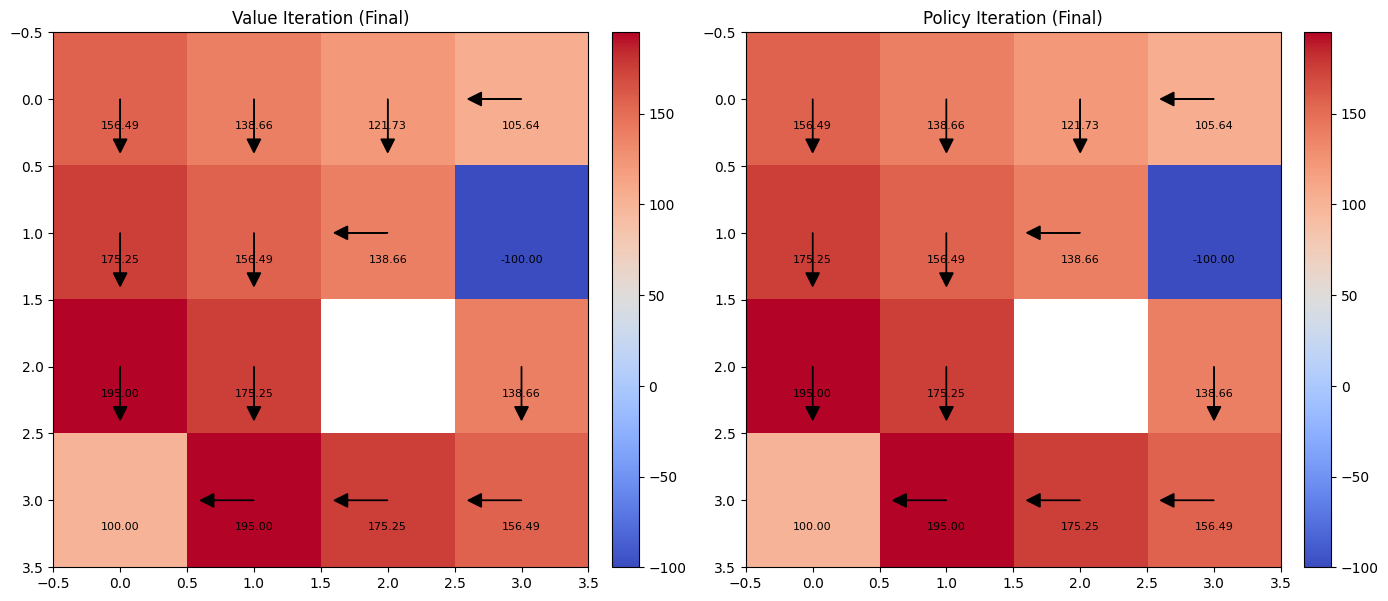

In [6]:
def compare_algorithms(vi_history, pi_instance, env):
    v_final_vi = vi_history[-1]
    policy_final_vi = extract_policy(env, v_final_vi, states, actions, pi_instance.gamma)
    
    v_final_pi = pi_instance.history_V[-1]
    policy_final_pi = pi_instance.history_policy[-1]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    def draw_on_axis(ax, V, policy, title):
        grid = np.zeros((env.size, env.size))
        for (i, j), v in V.items(): grid[i, j] = v
        
        display_grid = grid.copy()
        for (i, j) in env.walls: display_grid[i, j] = np.nan
        
        im = ax.imshow(display_grid, cmap='coolwarm', origin='upper')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        arrows = {'up': (0, -0.3), 'down': (0, 0.3), 'left': (-0.3, 0), 'right': (0.3, 0)}
        for i in range(env.size):
            for j in range(env.size):
                s = (i, j)
                if s in env.walls: continue
                ax.text(j, i+0.2, f"{V[s]:.2f}", ha='center', va='center', fontsize=8)
                if s in policy and not env.is_terminal(s):
                    dx, dy = arrows[policy[s]]
                    ax.arrow(j, i, dx, dy, head_width=0.1, head_length=0.1, fc='k', ec='k')
        ax.set_title(title)

    draw_on_axis(ax1, v_final_vi, policy_final_vi, "Value Iteration (Final)")
    draw_on_axis(ax2, v_final_pi, policy_final_pi, "Policy Iteration (Final)")
    
    plt.tight_layout()
    plt.show()

compare_algorithms(history, pi, env)